In [1]:
import os
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Configuration

Define paths and parameters for the experiment.

In [2]:
# Graphs to download and benchmark

graphs = ",".join([
    "road-usroads",
    # New York City
    # Colorado
    "road-belgium-osm",
    "road-roadNet-CA",

    "delaunay_n17",
    "delaunay_n18",
    "delaunay_n19",
    "delaunay_n20",
    "delaunay_n21",

    "soc-sign-epinions",
    "ca-citeseer",
    "soc-flickr",
    "soc-lastfm",
    "soc-flickr-und"
])

downloaded_graphs = [
    "USA-road-d.NY",
    "USA-road-d.COL"
]

# Directory for storing benchmark results
results_dir = "results"

# Directory containing graph files
graphs_dir = r"..\graphs"

## Step 1. Download selected graphs

We download the selected road, geometric, and social-like graphs into `../graphs` using the shared downloader script.

In [3]:
!python {graphs_dir}\download_graphs.py {graphs} --dir {graphs_dir}

=== Downloading 13 graph(s) to '..\graphs' ===
  [DOWNLOAD] road-usroads...
  [OK] road-usroads.mtx
    preview:
      %%MatrixMarket matrix coordinate pattern symmetric
      %-------------------------------------------------------------------------------
      % UF Sparse Matrix Collection, Tim Davis
      % http://www.cise.ufl.edu/research/sparse/matrices/Gleich/usroads
      % name: Gleich/usroads
  [DOWNLOAD] road-belgium-osm...
  [OK] road-belgium-osm.mtx
    preview:
      %%MatrixMarket matrix coordinate pattern symmetric
      %-------------------------------------------------------------------------------
      % UF Sparse Matrix Collection, Tim Davis
      % http://www.cise.ufl.edu/research/sparse/matrices/DIMACS10/belgium_osm
      % name: DIMACS10/belgium_osm
  [DOWNLOAD] road-roadNet-CA...
  [OK] road-roadNet-CA.mtx
    preview:
      %MatrixMarket matrix coordinate pattern symmetric
      1957027 1957027 2760388
      2 1
      3 1
      467 1
  [DOWNLOAD] delaunay_n17..

In [4]:
for graph in downloaded_graphs:
    !python {graphs_dir}\gr_to_mtx.py {graphs_dir}\{graph}.gr {graphs_dir}\{graph}.mtx

Reading ..\graphs\USA-road-d.NY.gr...
Found 264346 vertices and 733846 edges
Writing to ..\graphs\USA-road-d.NY.mtx...
✅ Conversion complete!
   Vertices: 264346
   Edges: 733846
   Type: symmetric
   Weighted: False
Reading ..\graphs\USA-road-d.COL.gr...
Found 435666 vertices and 1057066 edges
Writing to ..\graphs\USA-road-d.COL.mtx...
✅ Conversion complete!
   Vertices: 435666
   Edges: 1057066
   Type: symmetric
   Weighted: False


## Step 2. Add weights to graphs

SPLA implementation requires weighted edges in MTX format.
This step adds weights to pattern graphs using the formula: `weight = min(src, dst)`.

- Creates backup files (`.mtx.bak`) on first run
- Skips already processed files (if backup exists)
- Safe to re-run multiple times

In [5]:
all_graphs = graphs + "," + ",".join(downloaded_graphs)
!cd {graphs_dir} && python add_weights.py {all_graphs}

[OK] road-usroads.mtx.bak -> road-usroads.mtx (165435 edges)
[OK] road-belgium-osm.mtx.bak -> road-belgium-osm.mtx (1549970 edges)
[OK] road-roadNet-CA.mtx.bak -> road-roadNet-CA.mtx (2760388 edges)
[OK] delaunay_n17.mtx.bak -> delaunay_n17.mtx (393176 edges)
[OK] delaunay_n18.mtx.bak -> delaunay_n18.mtx (786396 edges)
[OK] delaunay_n19.mtx.bak -> delaunay_n19.mtx (1572823 edges)
[OK] delaunay_n20.mtx.bak -> delaunay_n20.mtx (3145686 edges)
[OK] delaunay_n21.mtx.bak -> delaunay_n21.mtx (6291408 edges)
[OK] soc-sign-epinions.mtx.bak -> soc-sign-epinions.mtx (711210 edges)
[OK] ca-citeseer.mtx.bak -> ca-citeseer.mtx (814134 edges)
[OK] soc-flickr.mtx.bak -> soc-flickr.mtx (3190452 edges)
[OK] soc-lastfm.mtx.bak -> soc-lastfm.mtx (4519330 edges)
[OK] soc-flickr-und.mtx.bak -> soc-flickr-und.mtx (15555041 edges)
[OK] USA-road-d.NY.mtx.bak -> USA-road-d.NY.mtx (365050 edges)
[OK] USA-road-d.COL.mtx.bak -> USA-road-d.COL.mtx (521200 edges)


## Step 3. Create results directory

Create a directory for storing benchmark results (CSV files, logs, etc.).

- If `results_dir` is a relative path, it will be interpreted relative to the current notebook working directory.
- If the directory already exists, it will not be modified.
- If the directory does not exist, it will be created (including any necessary parent directories).

In [6]:
results_path = Path(results_dir)

# If path is relative, interpret it relative to current notebook working directory
if not results_path.is_absolute():
    results_path = Path.cwd() / results_path

# Create directory only if it does not exist
results_path.mkdir(parents=True, exist_ok=True)

print(f"Results directory: {results_path}")
print(f"Exists: {results_path.exists()}")

Results directory: c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results
Exists: True


## Step 4. Run Spark benchmarks

Run Boruvka MST algorithm on Spark for each graph.

Each graph runs in a separate cell to allow partial re-execution if needed.

In [77]:
# Benchmark parameters
warmup = 3
runs = 5
cores = "*"

# Paths
spark_project_dir = r"..\boruvka_spark"

### Road Networks

In [78]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\road-usroads.mtx --csv={results_path}\spark_road-usroads.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\road-usroads.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_road-usroads.csv --runs=5 --warmup=3 --cores=*
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_5b304698/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider reporting th

In [79]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\road-belgium-osm.mtx --csv={results_path}\spark_road-belgium-osm.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\road-belgium-osm.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_road-belgium-osm.csv --runs=5 --warmup=3 --cores=*
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_77fda7b4/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider repo

In [80]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\road-roadNet-CA.mtx --csv={results_path}\spark_road-roadNet-CA.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\road-roadNet-CA.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_road-roadNet-CA.csv --runs=5 --warmup=3 --cores=*
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_d761b86e/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider report

In [81]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\USA-road-d.COL.mtx --csv={results_path}\spark_USA-road-d.COL.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\USA-road-d.COL.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_USA-road-d.COL.csv --runs=5 --warmup=3 --cores=*
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_30f158b5/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider reportin

In [82]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\USA-road-d.NY.mtx --csv={results_path}\spark_USA-road-d.NY.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\USA-road-d.NY.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_USA-road-d.NY.csv --runs=5 --warmup=3 --cores=*
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_2109bcc3/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider reporting 

### Triangulations / Geometric

In [83]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\delaunay_n17.mtx --csv={results_path}\spark_delaunay_n17.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\delaunay_n17.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_delaunay_n17.csv --runs=5 --warmup=3 --cores=*
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_c7f7859c/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider reporting th

In [84]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\delaunay_n18.mtx --csv={results_path}\spark_delaunay_n18.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\delaunay_n18.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_delaunay_n18.csv --runs=5 --warmup=3 --cores=*
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_39e88338/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider reporting th

In [85]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\delaunay_n19.mtx --csv={results_path}\spark_delaunay_n19.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\delaunay_n19.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_delaunay_n19.csv --runs=5 --warmup=3 --cores=*
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_c8b3384a/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider reporting th

In [86]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\delaunay_n20.mtx --csv={results_path}\spark_delaunay_n20.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\delaunay_n20.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_delaunay_n20.csv --runs=5 --warmup=3 --cores=*
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_1475035d/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider reporting th

In [87]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\delaunay_n21.mtx --csv={results_path}\spark_delaunay_n21.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\delaunay_n21.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_delaunay_n21.csv --runs=5 --warmup=3 --cores=*
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_4b1bfc46/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider reporting th

### Social / Collaboration

In [88]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\soc-sign-epinions.mtx --csv={results_path}\spark_soc-sign-epinions.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\soc-sign-epinions.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_soc-sign-epinions.csv --runs=5 --warmup=3 --cores=*
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_77b767f5/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider re

In [89]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\ca-citeseer.mtx --csv={results_path}\spark_ca-citeseer.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\ca-citeseer.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_ca-citeseer.csv --runs=5 --warmup=3 --cores=*
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_7c6d81ae/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider reporting this

In [90]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\soc-flickr.mtx --csv={results_path}\spark_soc-flickr.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\soc-flickr.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_soc-flickr.csv --runs=5 --warmup=3 --cores=*
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_fd48b0db/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider reporting this t

In [91]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\soc-lastfm.mtx --csv={results_path}\spark_soc-lastfm.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\soc-lastfm.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_soc-lastfm.csv --runs=5 --warmup=3 --cores=*
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_3195d89d/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider reporting this t

In [92]:
!cd {spark_project_dir} && sbt "run --graph={graphs_dir}\soc-flickr-und.mtx --csv={results_path}\spark_soc-flickr-und.csv --runs={runs} --warmup={warmup} --cores={cores}"

[info] welcome to sbt 1.9.7 (Eclipse Adoptium Java 11.0.30)
[info] loading project definition from C:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\boruvka_spark\project
[info] loading settings for project root from build.sbt ...
[info] set current project to boruvka_spark (in build file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/)
[info] running (fork) boruvka.Main --graph=..\graphs\soc-flickr-und.mtx --csv=c:\Users\d.kadochnikov\spbu\graphs\graphs_analysis\boruvka\experiment_graph_types\results\spark_soc-flickr-und.csv --runs=5 --warmup=3 --cores=*
[error] WARNING: An illegal reflective access operation has occurred
[error] WARNING: Illegal reflective access by org.apache.spark.unsafe.Platform (file:/C:/Users/d.kadochnikov/spbu/graphs/graphs_analysis/boruvka/boruvka_spark/target/bg-jobs/sbt_adc4ef18/target/40f64c8b/8e672e72/spark-unsafe_2.12-3.5.1.jar) to constructor java.nio.DirectByteBuffer(long,int)
[error] WARNING: Please consider reportin

## Step 5. Run SPLA benchmarks

Run Boruvka MST algorithm on SPLA for each graph.

Each graph runs in a separate cell to allow partial re-execution if needed.

In [93]:
# SPLA binary path
spla_binary = r"..\boruvka_spla\build\Debug\boruvka_spla.exe"

### Road Networks

In [94]:
!{spla_binary} --mtxpath {graphs_dir}\road-usroads.mtx --out {results_path}\spla_road-usroads.csv --niters {runs} --warmup {warmup} -p 1 -d 0

env: OpenCL Acc Intel(R) OpenCL device: 12th Gen Intel(R) Core(TM) i5-1235U vendor:intel mcu:12 wave:8 mwgs:8192


In [95]:
!{spla_binary} --mtxpath {graphs_dir}\road-belgium-osm.mtx --out {results_path}\spla_road-belgium-osm.csv --niters {runs} --warmup {warmup} -p 1 -d 0

env: OpenCL Acc Intel(R) OpenCL device: 12th Gen Intel(R) Core(TM) i5-1235U vendor:intel mcu:12 wave:8 mwgs:8192


In [96]:
!{spla_binary} --mtxpath {graphs_dir}\road-roadNet-CA.mtx --out {results_path}\spla_road-roadNet-CA.csv --niters {runs} --warmup {warmup} -p 1 -d 0

env: OpenCL Acc Intel(R) OpenCL device: 12th Gen Intel(R) Core(TM) i5-1235U vendor:intel mcu:12 wave:8 mwgs:8192


In [97]:
!{spla_binary} --mtxpath {graphs_dir}\USA-road-d.COL.mtx --out {results_path}\spla_USA-road-d.COL.csv --niters {runs} --warmup {warmup} -p 1 -d 0

env: OpenCL Acc Intel(R) OpenCL device: 12th Gen Intel(R) Core(TM) i5-1235U vendor:intel mcu:12 wave:8 mwgs:8192


In [98]:
!{spla_binary} --mtxpath {graphs_dir}\USA-road-d.NY.mtx --out {results_path}\spla_USA-road-d.NY.csv --niters {runs} --warmup {warmup} -p 1 -d 0

env: OpenCL Acc Intel(R) OpenCL device: 12th Gen Intel(R) Core(TM) i5-1235U vendor:intel mcu:12 wave:8 mwgs:8192


### Triangulations / Geometric

In [99]:
!{spla_binary} --mtxpath {graphs_dir}\delaunay_n17.mtx --out {results_path}\spla_delaunay_n17.csv --niters {runs} --warmup {warmup} -p 1 -d 0

env: OpenCL Acc Intel(R) OpenCL device: 12th Gen Intel(R) Core(TM) i5-1235U vendor:intel mcu:12 wave:8 mwgs:8192


In [100]:
!{spla_binary} --mtxpath {graphs_dir}\delaunay_n18.mtx --out {results_path}\spla_delaunay_n18.csv --niters {runs} --warmup {warmup} -p 1 -d 0

env: OpenCL Acc Intel(R) OpenCL device: 12th Gen Intel(R) Core(TM) i5-1235U vendor:intel mcu:12 wave:8 mwgs:8192


In [101]:
!{spla_binary} --mtxpath {graphs_dir}\delaunay_n19.mtx --out {results_path}\spla_delaunay_n19.csv --niters {runs} --warmup {warmup} -p 1 -d 0

env: OpenCL Acc Intel(R) OpenCL device: 12th Gen Intel(R) Core(TM) i5-1235U vendor:intel mcu:12 wave:8 mwgs:8192


In [102]:
!{spla_binary} --mtxpath {graphs_dir}\delaunay_n20.mtx --out {results_path}\spla_delaunay_n20.csv --niters {runs} --warmup {warmup} -p 1 -d 0

env: OpenCL Acc Intel(R) OpenCL device: 12th Gen Intel(R) Core(TM) i5-1235U vendor:intel mcu:12 wave:8 mwgs:8192


In [103]:
!{spla_binary} --mtxpath {graphs_dir}\delaunay_n21.mtx --out {results_path}\spla_delaunay_n21.csv --niters {runs} --warmup {warmup} -p 1 -d 0

env: OpenCL Acc Intel(R) OpenCL device: 12th Gen Intel(R) Core(TM) i5-1235U vendor:intel mcu:12 wave:8 mwgs:8192


### Social / Collaboration

In [104]:
!{spla_binary} --mtxpath {graphs_dir}\soc-sign-epinions.mtx --out {results_path}\spla_soc-sign-epinions.csv --niters {runs} --warmup {warmup} -p 1 -d 0

env: OpenCL Acc Intel(R) OpenCL device: 12th Gen Intel(R) Core(TM) i5-1235U vendor:intel mcu:12 wave:8 mwgs:8192


In [105]:
!{spla_binary} --mtxpath {graphs_dir}\ca-citeseer.mtx --out {results_path}\spla_ca-citeseer.csv --niters {runs} --warmup {warmup} -p 1 -d 0

env: OpenCL Acc Intel(R) OpenCL device: 12th Gen Intel(R) Core(TM) i5-1235U vendor:intel mcu:12 wave:8 mwgs:8192


In [106]:
!{spla_binary} --mtxpath {graphs_dir}\soc-flickr.mtx --out {results_path}\spla_soc-flickr.csv --niters {runs} --warmup {warmup} -p 1 -d 0

env: OpenCL Acc Intel(R) OpenCL device: 12th Gen Intel(R) Core(TM) i5-1235U vendor:intel mcu:12 wave:8 mwgs:8192


In [107]:
!{spla_binary} --mtxpath {graphs_dir}\soc-lastfm.mtx --out {results_path}\spla_soc-lastfm.csv --niters {runs} --warmup {warmup} -p 1 -d 0

env: OpenCL Acc Intel(R) OpenCL device: 12th Gen Intel(R) Core(TM) i5-1235U vendor:intel mcu:12 wave:8 mwgs:8192


In [108]:
!{spla_binary} --mtxpath {graphs_dir}\soc-flickr-und.mtx --out {results_path}\spla_soc-flickr-und.csv --niters {runs} --warmup {warmup} -p 1 -d 0

env: OpenCL Acc Intel(R) OpenCL device: 12th Gen Intel(R) Core(TM) i5-1235U vendor:intel mcu:12 wave:8 mwgs:8192


## Step 6. Load and analyze results

Read all benchmark CSV files from the results directory, parse them into a unified DataFrame, and compute summary statistics.

CSV format (same for both Spark and SPLA):

library,graph,vertices,edges,cores,mst_weight,mst_edges,time_ms

Each row is one benchmark run.

In [115]:
graph_types = {
    # Road Networks
    "road-usroads": "Road",
    "road-belgium-osm": "Road",
    "road-roadNet-CA": "Road",
    "USA-road-d.NY": "Road",
    "USA-road-d.COL": "Road",
    
    # Geometric Graphs
    "delaunay_n17": "Geometric",
    "delaunay_n18": "Geometric",
    "delaunay_n19": "Geometric",
    "delaunay_n20": "Geometric",
    "delaunay_n21": "Geometric",

    # Social & Collaboration Networks
    "soc-sign-epinions": "Social",
    "ca-citeseer": "Social",
    "soc-flickr": "Social",
    "soc-lastfm": "Social",
    "soc-flickr-und": "Social",
}

def load_all_results(results_dir: Path) -> pd.DataFrame:
    dfs = []
    
    for csv_file in sorted(results_dir.glob("*.csv")):
        name = csv_file.stem
        parts = name.split("_", 1)
        if len(parts) != 2:
            print(f"[SKIP] Unexpected filename: {csv_file.name}")
            continue
        
        library = parts[0].upper()
        graph_name = parts[1]
        graph_type = graph_types.get(graph_name, "Unknown")
        
        try:
            df = pd.read_csv(csv_file)
            df.columns = df.columns.str.strip()
            df["time_ms"] = df["time_ms"].astype(str).str.replace(",", ".").astype(float)
            df["library"] = library
            df["graph"] = graph_name
            df["graph_type"] = graph_type
            dfs.append(df)
        except Exception as e:
            print(f"[ERROR] {csv_file.name}: {e}")
            continue
    
    if not dfs:
        print("No CSV files found!")
        return pd.DataFrame()
    
    return pd.concat(dfs, ignore_index=True)

df = load_all_results(results_path)
print(f"Total records: {len(df)}")
print(f"Libraries: {df['library'].unique()}")
print(f"Graphs: {df['graph'].unique()}")
print(f"Graph types: {df['graph_type'].unique()}")
df.head(10)

Total records: 150
Libraries: <StringArray>
['SPARK', 'SPLA']
Length: 2, dtype: str
Graphs: <StringArray>
[      'ca-citeseer',      'delaunay_n17',      'delaunay_n18',
      'delaunay_n19',      'delaunay_n20',      'delaunay_n21',
  'road-belgium-osm',   'road-roadNet-CA',      'road-usroads',
    'soc-flickr-und',        'soc-flickr',        'soc-lastfm',
 'soc-sign-epinions',    'USA-road-d.COL',     'USA-road-d.NY']
Length: 15, dtype: str
Graph types: <StringArray>
['Social', 'Geometric', 'Road']
Length: 3, dtype: str


,library,graph,vertices,edges,cores,mst_weight,mst_edges,time_ms,graph_type
0,SPARK,ca-citeseer,227320,814134,12,-1.393899e+09,227319,10262.78,Social
1,SPARK,ca-citeseer,227320,814134,12,-1.393899e+09,227319,10038.24,Social
2,SPARK,ca-citeseer,227320,814134,12,-1.393899e+09,227319,10125.34,Social
3,SPARK,ca-citeseer,227320,814134,12,-1.393899e+09,227319,9827.21,Social
4,SPARK,ca-citeseer,227320,814134,12,-1.393899e+09,227319,9911.00,Social
5,SPARK,delaunay_n17,131072,393176,12,-2.859704e+08,131071,7606.11,Geometric
6,SPARK,delaunay_n17,131072,393176,12,-2.859704e+08,131071,7827.06,Geometric
7,SPARK,delaunay_n17,131072,393176,12,-2.859704e+08,131071,7449.24,Geometric
8,SPARK,delaunay_n17,131072,393176,12,-2.859704e+08,131071,7538.43,Geometric
9,SPARK,delaunay_n17,131072,393176,12,-2.859704e+08,131071,7370.10,Geometric


In [116]:
summary = df.groupby(["library", "graph", "graph_type", "vertices", "edges"]).agg(
    mean_time_ms=("time_ms", "mean"),
    std_time_ms=("time_ms", "std"),
    min_time_ms=("time_ms", "min"),
    max_time_ms=("time_ms", "max"),
    runs=("time_ms", "count"),
).reset_index()

summary["std_time_ms"] = summary["std_time_ms"].fillna(0)
summary = summary.sort_values(["graph_type", "vertices", "library"])

display_cols = ["library", "graph_type", "graph", "vertices", "edges", "mean_time_ms", "std_time_ms", "runs"]
summary[display_cols].round(2)

,library,graph_type,graph,vertices,edges,mean_time_ms,std_time_ms,runs
3,SPARK,Geometric,delaunay_n17,131072,393176,7558.19,174.80,5
18,SPLA,Geometric,delaunay_n17,131072,786352,601.97,4.42,5
4,SPARK,Geometric,delaunay_n18,262144,786396,12885.65,373.96,5
19,SPLA,Geometric,delaunay_n18,262144,1572792,1209.85,8.89,5
5,SPARK,Geometric,delaunay_n19,524288,1572823,19613.96,464.14,5
20,SPLA,Geometric,delaunay_n19,524288,3145646,2391.03,7.72,5
6,SPARK,Geometric,delaunay_n20,1048576,3145686,33598.34,1101.00,5
21,SPLA,Geometric,delaunay_n20,1048576,6291372,4853.90,45.35,5
7,SPARK,Geometric,delaunay_n21,2097152,6291408,75115.43,11062.30,5
22,SPLA,Geometric,delaunay_n21,2097152,12582816,9878.78,60.07,5


## Step 7. Visualization

Focus: How does graph type affect relative performance of Spark vs SPLA?

Three graph families:
- **Road** — sparse, planar, many Borůvka iterations
- **Geometric** — triangulation, moderate density
- **Social** — dense communities, few Borůvka iterations

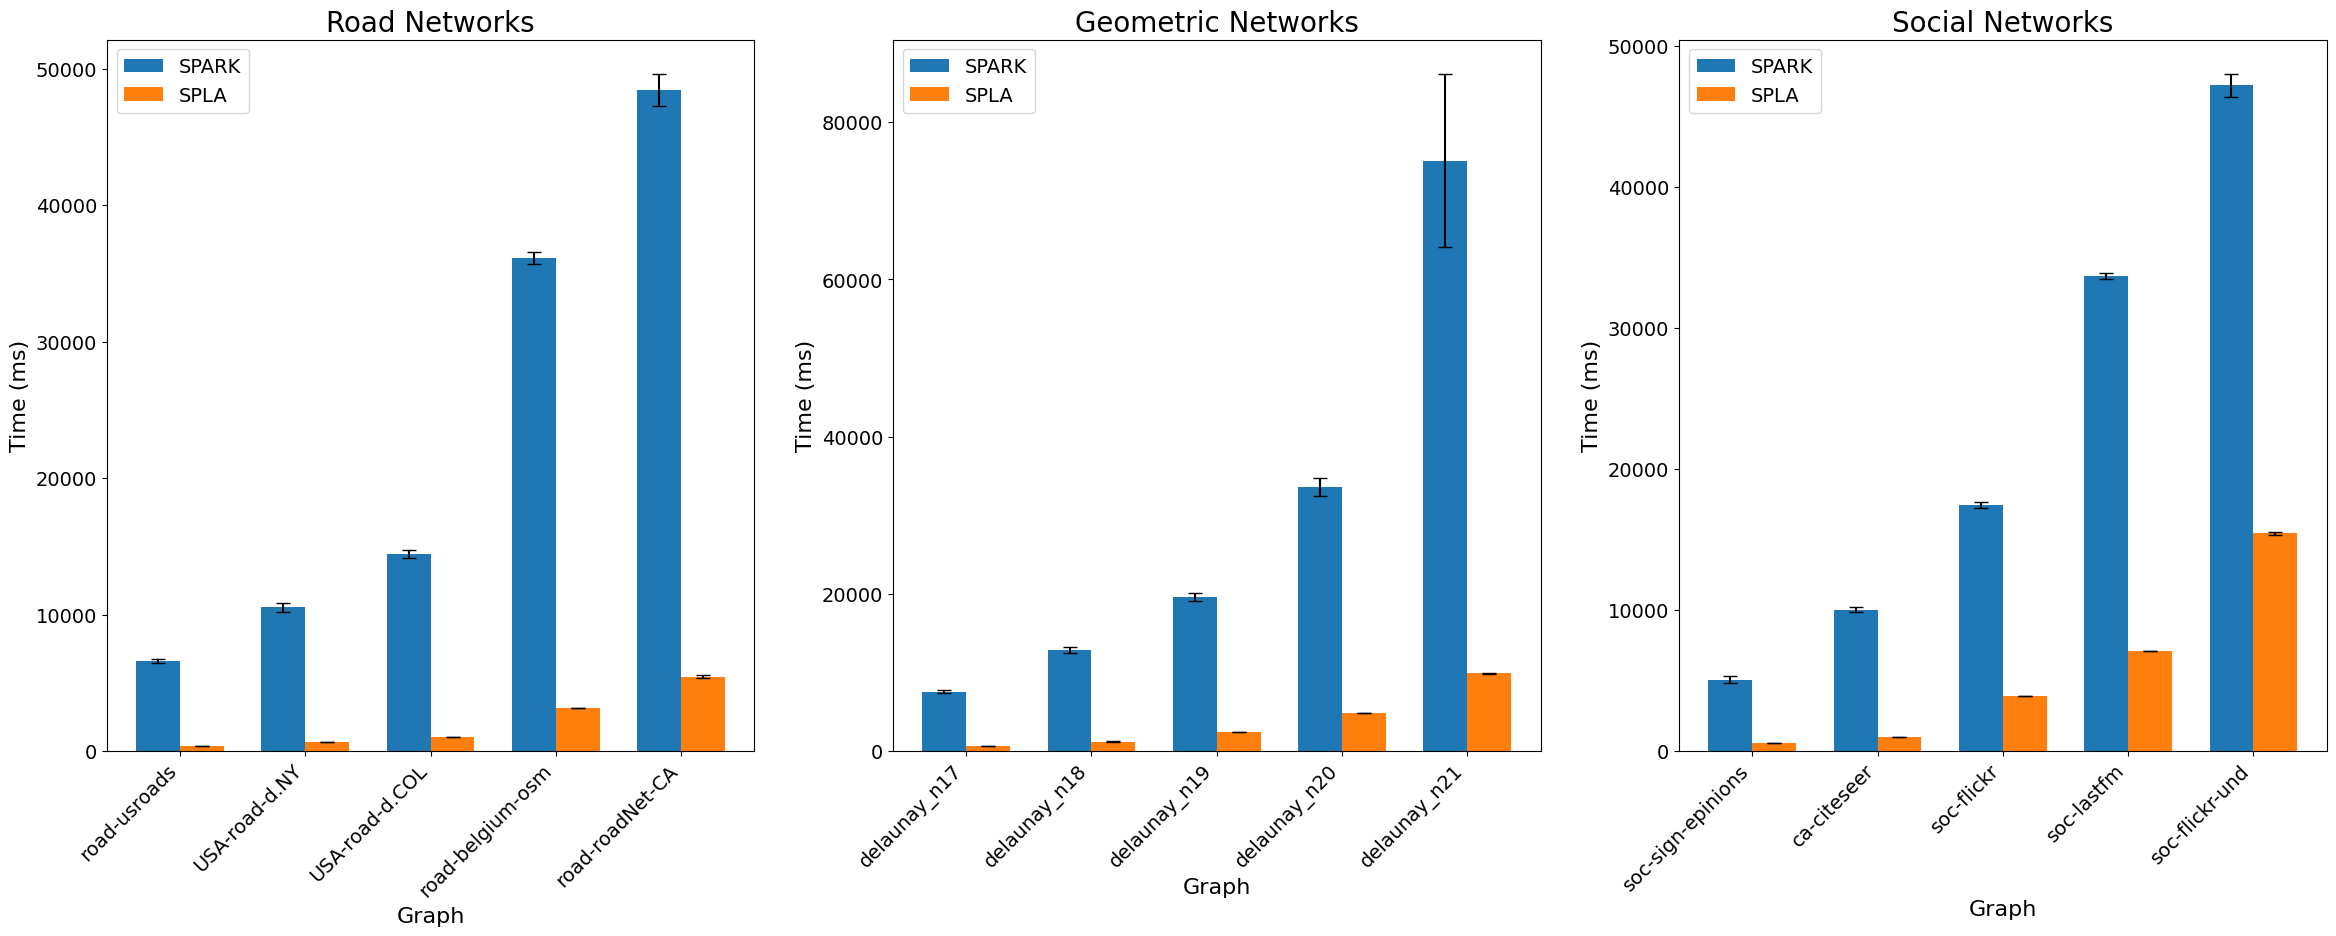

In [117]:
# fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False) # СТАРАЯ СТРОКА
fig, axes = plt.subplots(1, 3, figsize=(24, 10), sharey=False) # <<< ИЗМЕНЕНИЕ: Увеличили размер всей фигуры

for idx, gtype in enumerate(["Road", "Geometric", "Social"]):
    ax = axes[idx]
    subset = summary[summary["graph_type"] == gtype].sort_values("vertices")
    
    graphs = subset["graph"].unique()
    x = np.arange(len(graphs))
    width = 0.35
    
    for i, lib in enumerate(["SPARK", "SPLA"]):
        # ... (ваш код для построения баров остается без изменений)
        lib_data = subset[subset["library"] == lib]
        times = []
        stds = []
        for g in graphs:
            row = lib_data[lib_data["graph"] == g]
            if len(row) > 0:
                times.append(row["mean_time_ms"].values[0])
                stds.append(row["std_time_ms"].values[0])
            else:
                times.append(0)
                stds.append(0)
        
        offset = -width/2 + i * width
        ax.bar(x + offset, times, width, yerr=stds, label=lib, capsize=5) # <<< ИЗМЕНЕНИЕ: Увеличили capsize для наглядности
    
    # --- Увеличиваем размеры шрифтов ---
    ax.set_xlabel("Graph", fontsize=16) # <<< ИЗМЕНЕНИЕ
    ax.set_ylabel("Time (ms)", fontsize=16) # <<< ИЗМЕНЕНИЕ
    ax.set_title(f"{gtype} Networks", fontsize=20) # <<< ИЗМЕНЕНИЕ
    ax.set_xticks(x)
    ax.set_xticklabels(graphs, rotation=45, ha="right", fontsize=14) # <<< ИЗМЕНЕНИЕ
    ax.tick_params(axis='y', labelsize=14) # <<< ИЗМЕНЕНИЕ: Размер чисел на оси Y
    ax.legend(fontsize=14) # <<< ИЗМЕНЕНИЕ

# plt.tight_layout() # СТАРАЯ СТРОКА
plt.tight_layout(pad=3.0) # <<< ИЗМЕНЕНИЕ: Добавили отступ между графиками

# plt.savefig(str(results_path / "comparison_by_graph_type.png"), dpi=150, bbox_inches="tight") # СТАРАЯ СТРОКА
plt.savefig(str(results_path / "comparison_by_graph_type.png"), dpi=300, bbox_inches="tight") # <<< ИЗМЕНЕНИЕ: Увеличили DPI для четкости
plt.show()

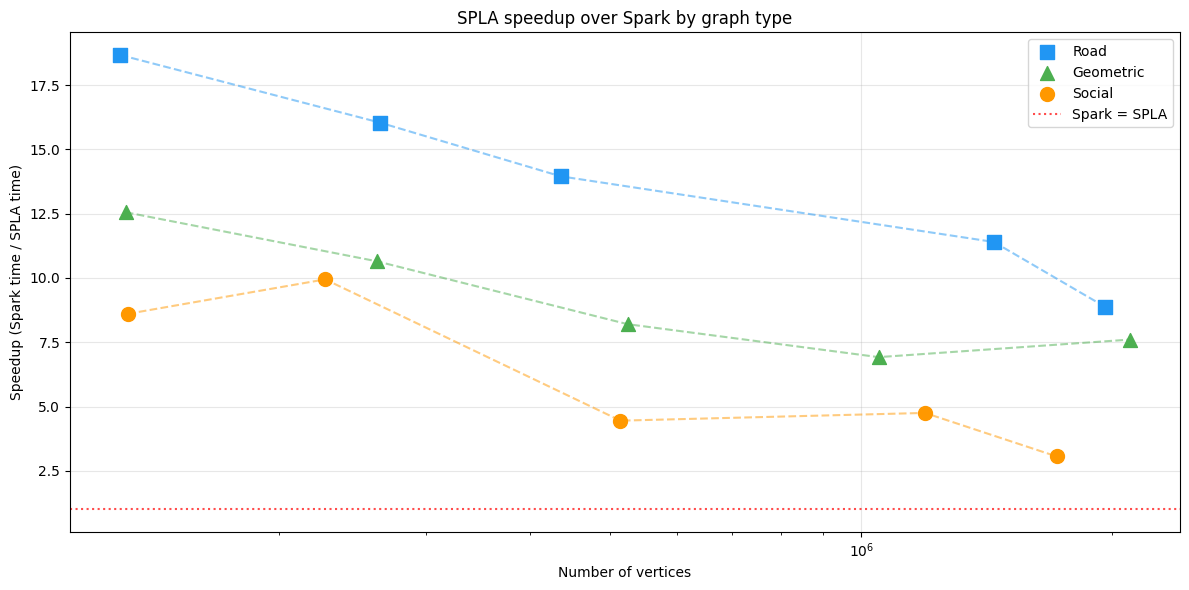

In [118]:
pivot = summary.pivot_table(
    index=["graph", "graph_type", "vertices"],
    columns="library",
    values="mean_time_ms"
).reset_index()

if "SPARK" in pivot.columns and "SPLA" in pivot.columns:
    pivot["speedup"] = pivot["SPARK"] / pivot["SPLA"]
    pivot = pivot.sort_values("vertices")
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = {"Road": "#2196F3", "Geometric": "#4CAF50", "Social": "#FF9800"}
    markers = {"Road": "s", "Geometric": "^", "Social": "o"}
    
    for gtype in ["Road", "Geometric", "Social"]:
        subset = pivot[pivot["graph_type"] == gtype]
        ax.scatter(subset["vertices"], subset["speedup"],
                   c=colors[gtype], marker=markers[gtype], s=100, label=gtype, zorder=5)
        ax.plot(subset["vertices"], subset["speedup"],
                c=colors[gtype], linestyle="--", alpha=0.5)
    
    ax.axhline(y=1.0, color="red", linestyle=":", alpha=0.7, label="Spark = SPLA")
    ax.set_xlabel("Number of vertices")
    ax.set_ylabel("Speedup (Spark time / SPLA time)")
    ax.set_title("SPLA speedup over Spark by graph type")
    ax.set_xscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(str(results_path / "speedup_by_graph_type.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Not enough data. Need both SPARK and SPLA results.")

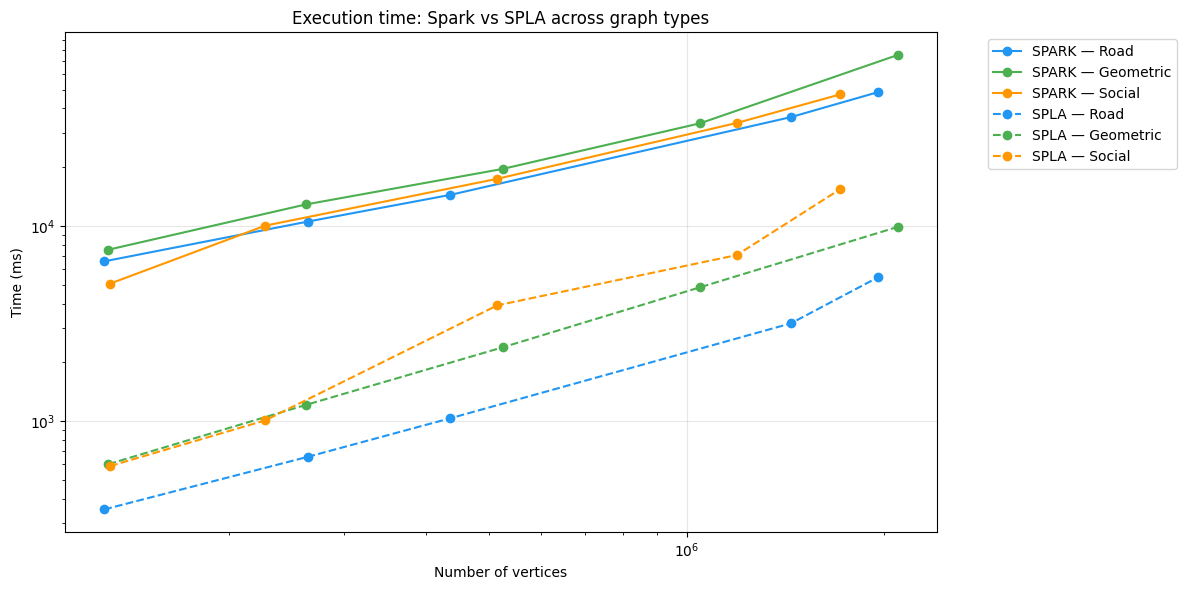

In [119]:
fig, ax = plt.subplots(figsize=(12, 6))

line_styles = {"SPARK": "-", "SPLA": "--"}
colors = {"Road": "#2196F3", "Geometric": "#4CAF50", "Social": "#FF9800"}

for lib in ["SPARK", "SPLA"]:
    for gtype in ["Road", "Geometric", "Social"]:
        subset = summary[(summary["library"] == lib) & (summary["graph_type"] == gtype)]
        subset = subset.sort_values("vertices")
        if len(subset) > 0:
            label = f"{lib} — {gtype}"
            ax.plot(subset["vertices"], subset["mean_time_ms"],
                    linestyle=line_styles[lib], color=colors[gtype],
                    marker="o", markersize=6, label=label)

ax.set_xlabel("Number of vertices")
ax.set_ylabel("Time (ms)")
ax.set_title("Execution time: Spark vs SPLA across graph types")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(results_path / "time_by_type_and_size.png"), dpi=150, bbox_inches="tight")
plt.show()

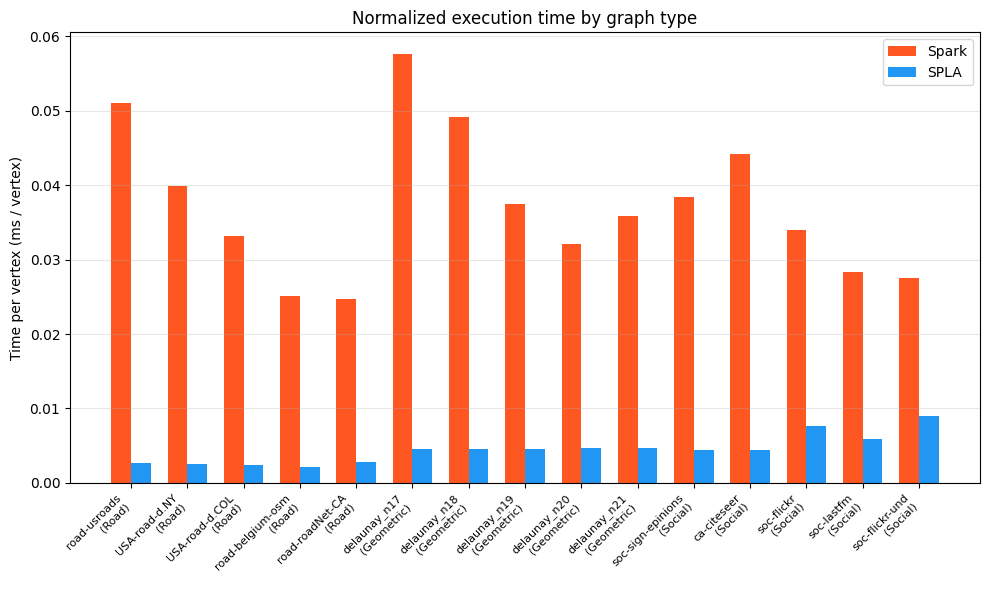

In [120]:
summary["time_per_vertex"] = summary["mean_time_ms"] / summary["vertices"]

fig, ax = plt.subplots(figsize=(10, 6))

x_labels = []
spark_vals = []
spla_vals = []

for gtype in ["Road", "Geometric", "Social"]:
    gtype_data = summary[summary["graph_type"] == gtype].sort_values("vertices")
    for graph_name in gtype_data["graph"].unique():
        spark_row = gtype_data[(gtype_data["graph"] == graph_name) & (gtype_data["library"] == "SPARK")]
        spla_row = gtype_data[(gtype_data["graph"] == graph_name) & (gtype_data["library"] == "SPLA")]
        
        if len(spark_row) > 0 and len(spla_row) > 0:
            x_labels.append(f"{graph_name}\n({gtype})")
            spark_vals.append(spark_row["time_per_vertex"].values[0])
            spla_vals.append(spla_row["time_per_vertex"].values[0])

x = np.arange(len(x_labels))
width = 0.35

ax.bar(x - width/2, spark_vals, width, label="Spark", color="#FF5722")
ax.bar(x + width/2, spla_vals, width, label="SPLA", color="#2196F3")

ax.set_ylabel("Time per vertex (ms / vertex)")
ax.set_title("Normalized execution time by graph type")
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(str(results_path / "time_per_vertex.png"), dpi=150, bbox_inches="tight")
plt.show()